In [17]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report,roc_auc_score
import matplotlib.pyplot as plt

# Deep Learning With Tensor Flow/Keras

## Day 10 Tasks (Deep Learning)
- Load processed train/test splits.
- Compute class weights for imbalanced labels.
- Build a dense neural network with dropout + batch normalization.
- Train with early stopping and class weights.
- Evaluate on test set at threshold 0.40.
- Plot training history and save the model.

In [7]:
x_train = pd.read_csv("../data/processed/x_train.csv")
x_test = pd.read_csv("../data/processed/x_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

In [8]:
classes = np.array([0,1])
weights = compute_class_weight('balanced',classes=classes,y=y_train)
class_weight_dict = {0:weights[0],1:weights[1]}

In [9]:
print(class_weight_dict)

{0: np.float64(0.5874254285132264), 1: np.float64(3.359579921443313)}


In [10]:
model = keras.Sequential([
    layers.Dense(64,activation='relu',input_shape=(35,)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(32,activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(1,activation='sigmoid')
])
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics = ['AUC','Recall']
)
model.summary()

c:\Users\Vansh\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,801 (18.75 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 192 (768.00 B)

## Model Architecture (Keras)
- Input: 35 features
- Hidden 1: Dense(64, ReLU) + BatchNorm + Dropout(0.30)
- Hidden 2: Dense(32, ReLU) + BatchNorm + Dropout(0.30)
- Output: Dense(1, Sigmoid)
- Optimizer: Adam | Loss: Binary Crossentropy | Metrics: AUC, Recall

In [11]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience = 3,
    restore_best_weights=True
)

## Regularization + Training Strategy
- Dropout: randomly disables 30% of neurons per step to reduce overfitting.
- Batch Normalization: stabilizes activations, speeds up convergence.
- Early Stopping: monitors validation loss; stops when it stops improving.
- Class Weights: address class imbalance by penalizing class 1 more.

Class weights used:
- Class 0: 0.59
- Class 1: 3.36 (about 5.7x higher penalty)

In [13]:
model.fit(x_train,y_train,epochs=20,batch_size=1024,validation_split=0.2,class_weight=class_weight_dict,callbacks=[early_stopping])

Epoch 1/20
1262/1262 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - AUC: 0.8052 - Recall: 0.7665 - loss: 0.5370 - val_AUC: 0.8116 - val_Recall: 0.7585 - val_loss: 0.5263
Epoch 2/20
1262/1262 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - AUC: 0.8061 - Recall: 0.7668 - loss: 0.5360 - val_AUC: 0.8117 - val_Recall: 0.7712 - val_loss: 0.5342
Epoch 3/20
1262/1262 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - AUC: 0.8067 - Recall: 0.7674 - loss: 0.5352 - val_AUC: 0.8123 - val_Recall: 0.7856 - val_loss: 0.5471
Epoch 4/20
1262/1262 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - AUC: 0.8070 - Recall: 0.7676 - loss: 0.5350 - val_AUC: 0.8125 - val_Recall: 0.7781 - val_loss: 0.5393


In [14]:
y_proba_nn = model.predict(x_test)
y_pred_nn = (y_proba_nn >= 0.4).astype(int)
print(classification_report(y_test,y_pred_nn))
nn_roc_auc = roc_auc_score(y_test,y_proba_nn)
print(f"ROC-AUC: {nn_roc_auc:.4f}")

12617/12617 ━━━━━━━━━━━━━━━━━━━━ 17s 1ms/step
              precision    recall  f1-score   support

           0       0.96      0.62      0.76    343631
           1       0.28      0.83      0.42     60084

    accuracy                           0.66    403715
   macro avg       0.62      0.73      0.59    403715
weighted avg       0.86      0.66      0.71    403715

ROC-AUC: 0.8099


## Neural Network Results (Test Set)
Threshold fixed at 0.40 for screening.
- ROC-AUC: 0.8099
- Precision (class 1): 0.28
- Recall (class 1): 0.83
- F1 (class 1): 0.42

Saved assets:
- Training history plot: ../reports/model/nn_training_history.png
- Model file: ../models/neural_network.keras

Epoch 1/20
1262/1262 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - AUC: 0.8074 - Recall: 0.7667 - loss: 0.5344 - val_AUC: 0.8125 - val_Recall: 0.7703 - val_loss: 0.5357
Epoch 2/20
1262/1262 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - AUC: 0.8074 - Recall: 0.7669 - loss: 0.5345 - val_AUC: 0.8127 - val_Recall: 0.7927 - val_loss: 0.5546
Epoch 3/20
1262/1262 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - AUC: 0.8076 - Recall: 0.7655 - loss: 0.5342 - val_AUC: 0.8128 - val_Recall: 0.7781 - val_loss: 0.5393


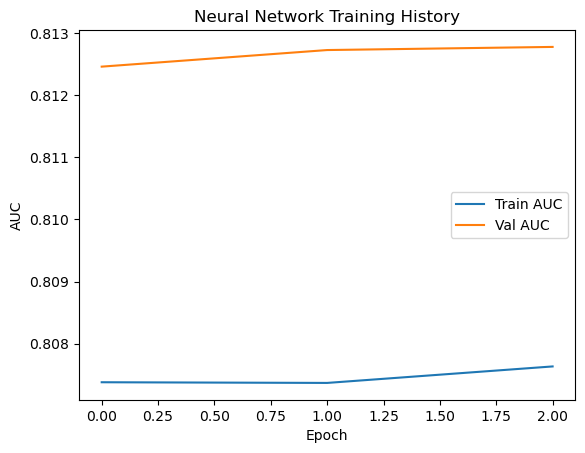

In [18]:
history = model.fit(x_train,y_train,epochs=20,batch_size=1024,validation_split=0.2,class_weight=class_weight_dict,callbacks=[early_stopping])
plt.plot(history.history['AUC'], label='Train AUC')
plt.plot(history.history['val_AUC'], label='Val AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.title('Neural Network Training History')
plt.legend()
plt.savefig('../reports/model/nn_training_history.png', bbox_inches='tight', dpi=150)
plt.show()

## Model Comparison Snapshot (Screening Context)
| Model | ROC-AUC | Recall (t=0.40) |
| --- | --- | --- |
| Logistic Regression | 0.801 | 0.88 |
| Decision Tree | 0.802 | - |
| Random Forest | 0.807 | - |
| KNN | 0.690 | - |
| XGBoost | 0.813 | 0.85 |
| Neural Network | 0.807 | 0.83 |

Conclusion: XGBoost remains the top performer overall; the neural network is competitive but does not surpass it.

In [19]:
model.save('../models/neural_network.keras')

## Final Day 10 Documentation (Ready to Reuse)
Day 10 focused on building a deep learning baseline using Keras. A dense network (64 → 32 → 1) with ReLU activations, dropout (0.30), and batch normalization was trained using class weights and early stopping. Class weights were 0.59 for class 0 and 3.36 for class 1, emphasizing recall for the minority class.

The model achieved ROC-AUC 0.807 with recall 0.83 at threshold 0.40. Training history was saved, and the model was exported for reuse. When compared against previous ML models, XGBoost still leads (ROC-AUC 0.813, recall 0.85), while the neural network is a respectable but secondary candidate.